<a href="https://colab.research.google.com/github/E-tech-coder/heart-disease-prediction/blob/main/Predicting_Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

In [4]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s6e2_path = kagglehub.competition_download('playground-series-s6e2')
print('Data source import complete.')
print(playground_series_s6e2_path)

100%|██████████| 10.2M/10.2M [00:00<00:00, 146MB/s]

Extracting files...


Data source import complete.
/root/.cache/kagglehub/competitions/playground-series-s6e2


# 1. Problem Definition

In [43]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
import sklearn.metrics as metrics


# 2. Data Understanding

In [6]:
train = pd.read_csv("/root/.cache/kagglehub/competitions/playground-series-s6e2/train.csv")
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [7]:
train.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [8]:
train.head(5)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [9]:
train.shape

(630000, 15)

There are 630000 rows in the training dataset, 15 features are all numerical.

# 3. Data Cleaning

Encode the target column and remove unnecessary columns.

In [10]:
DiseaseMatch = {"Presence":1, "Absence":0}
train["Disease"] = train["Heart Disease"].map(DiseaseMatch)

In [11]:
train = train.drop(columns = ["id", "Heart Disease"])

# 4. Exploratory Data Analysis (EDA)

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

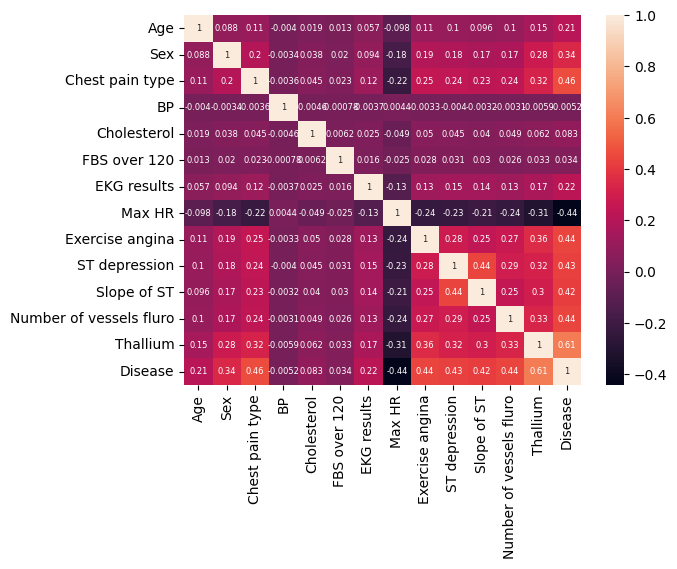

In [13]:
sns.heatmap(train.corr(), annot = True, annot_kws = {"size":6})

Maximum Heart Rate (Max HR) has a negative relationship with getting heart disease.

Chest Pain type, Exercise angina, ST depression, Slope of ST and Thallium have a positive relationship with getting heart disease.

BP, Cholesterol, FBS over 120 show weak connection with getting heart disease.

<Axes: xlabel='Disease', ylabel='count'>

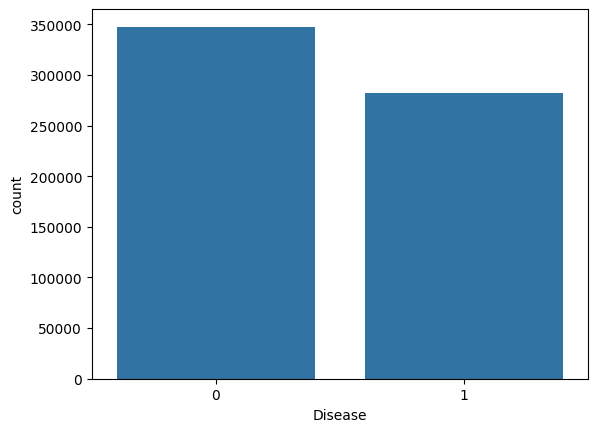

In [14]:
sns.countplot(x = "Disease", data = train)

There are around 350000 records for negative heart disease and 290000 records for positive heart disease. No serious class imbalance displayed.

# 5. Feature Engineering - Logistic regression


In [48]:
X = train.drop(columns = "Disease")
y = train["Disease"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns, index = X_train.index)
X_test = pd.DataFrame(scaler.fit_transform(X_test), columns = X_test.columns, index = X_test.index)

# 6. Model Building - Logistic regression

In [17]:
# Loop through a range of C values to decide which extent of penalty gives the best accuracy
cs = np.logspace(-8,8,30)

for c in cs :
  model = LogisticRegression(
    max_iter=1000,
    random_state = 42,
    solver = "liblinear",
    penalty = "l1", # Using penalty to select the most useful features
    warm_start = True, # keep the coeficients from the previous training
    C = c)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  print(f"The accuracy of C {c} is {accuracy}")

The accuracy of C 1e-08 is 0.5520952380952381
The accuracy of C 3.562247890262444e-08 is 0.5520952380952381
The accuracy of C 1.2689610031679235e-07 is 0.5520952380952381
The accuracy of C 4.5203536563602405e-07 is 0.5520952380952381
The accuracy of C 1.6102620275609392e-06 is 0.5520952380952381
The accuracy of C 5.736152510448681e-06 is 0.5520952380952381
The accuracy of C 2.0433597178569398e-05 is 0.8513492063492063
The accuracy of C 7.278953843983146e-05 is 0.8783730158730159
The accuracy of C 0.0002592943797404667 is 0.8816587301587302
The accuracy of C 0.0009236708571873865 is 0.8821746031746032
The accuracy of C 0.003290344562312671 is 0.8821349206349206
The accuracy of C 0.011721022975334793 is 0.8821031746031746
The accuracy of C 0.041753189365604 is 0.8821111111111111
The accuracy of C 0.14873521072935117 is 0.8821031746031746
The accuracy of C 0.5298316906283702 is 0.882095238095238
The accuracy of C 1.8873918221350996 is 0.882095238095238
The accuracy of C 6.723357536499335 

Model is underfitted with C <= 5.7361e-06, the penalty is too big.
Model is well fitted with C around 0.001, the accuracy plateau there is 0.8821.

In [18]:
model.classes_ # {"Presence":1, "Absence":0}

array([0, 1])

In [19]:
# Predict the probability of heart disease in the test dataset

test = pd.read_csv("/root/.cache/kagglehub/competitions/playground-series-s6e2/test.csv").drop(columns = "id")
submission = pd.read_csv("/root/.cache/kagglehub/competitions/playground-series-s6e2/sample_submission.csv")

In [47]:
test = pd.DataFrame(scaler.fit_transform(test), columns = test.columns, index = test.index)

model = LogisticRegression(
    max_iter=1000,
    random_state = 42,
    solver = "liblinear",
    penalty = "l1", # Using penalty to select the most useful features
    warm_start = True, # keep the coeficients from the previous training
    C = 0.001)
model.fit(X_train,y_train)
test_prob = model.predict_proba(test)

In [21]:
Probs = []
for i in range(len(test_prob)):
  Probs.append(round(test_prob[i][1],3))

In [22]:
submission["Heart Disease"] = Probs

In [23]:
submission = submission.set_index("id")

In [24]:
submission.to_csv("Submission_heartDisease.csv")

# 7. Model Evaluation - Logistic regression

Plot the ROC curve for logistic regression model.

In [50]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

AUC: 0.9502


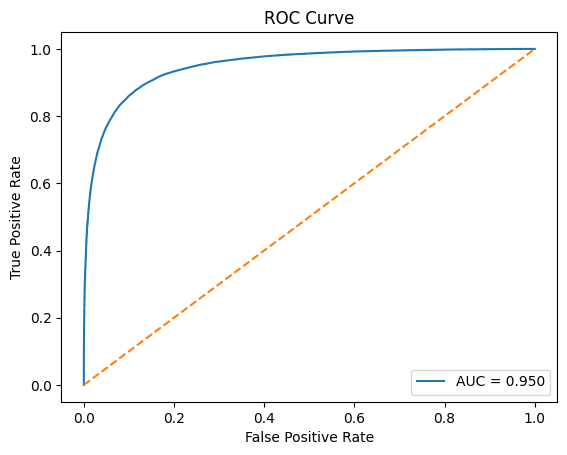

In [26]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr,tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Classification report

In [27]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69564
           1       0.88      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



Calculate log loss

In [51]:
loss = log_loss(y_test, y_prob)
print(f"Log Loss: {loss}")

Log Loss: 0.28290707300368567


#8. Model Building - XGBoost

In [32]:
import xgboost as xgb

dtrain_clf = xgb.DMatrix(X_train, y_train, enable_categorical = True)
dtest_clf = xgb.DMatrix(X_test, y_test, enable_categorical = True)

params = {"objective": "binary:logistic", "tree_method": "hist"}
n = 1000

evals = [(dtrain_clf, "train"), (dtest_clf, "validation")]

model = xgb.train(
    params = params,
    dtrain = dtrain_clf,
    num_boost_round = n,
    early_stopping_rounds=50,
    evals = evals,
    verbose_eval = 20
)


[0]	train-logloss:0.52985	validation-logloss:0.54826
[20]	train-logloss:0.26967	validation-logloss:0.32491
[40]	train-logloss:0.26482	validation-logloss:0.32767
[60]	train-logloss:0.26224	validation-logloss:0.32881
[64]	train-logloss:0.26183	validation-logloss:0.32931


#9. Model Evaluation - XGBoost

Cross evaluation

In [42]:
results = xgb.cv(
   params,
   dtrain_clf,
   num_boost_round=100,
   nfold=3,
   early_stopping_rounds=20,
   metrics = ["auc", "logloss"]
)

In [45]:
results.head()

,train-auc-mean,train-auc-std,train-logloss-mean,train-logloss-std,test-auc-mean,test-auc-std,test-logloss-mean,test-logloss-std
0,0.939510,0.000212,0.529857,0.000232,0.939225,0.000575,0.529971,0.000154
1,0.944960,0.000252,0.443199,0.000371,0.944566,0.000389,0.443531,0.000262
2,0.946686,0.000327,0.389550,0.000400,0.946247,0.000245,0.390131,0.000401
3,0.948332,0.000287,0.354453,0.000467,0.947795,0.000455,0.355233,0.000621
4,0.949349,0.000084,0.330734,0.000442,0.948799,0.000645,0.331681,0.000846


In [41]:
preds = model.predict(dtest_clf)
loss = log_loss(y_test, preds)
print(f"Log loss: {loss}")


Log loss: 0.3293073095916961


# 8. Conclusion

Log loss:

logistic regression:0.283

XGBoost : 0.329